In [1]:
import sys
print("Jupyter Python:", sys.executable)
!"{sys.executable}" -m pip install bertopic sentence-transformers hdbscan umap-learn scikit-learn

Jupyter Python: c:\Users\TAHA\AppData\Local\Programs\Python\Python313\python.exe


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Konu Modelleme (Topic Modeling) - Şikayet ve Övgü Analizi

Bu notebook'ta, BERT modeli tarafından "positive" ve "negative" olarak ayrıştırılmış yorumların içeriğini inceleyeceğiz. 
Amacımız, kullanıcıların en çok neden şikayet ettiğini ve neyi övdüğünü gruplayarak işletmeye (veya geliştiriciye) net eylem planları sunmaktır.

In [2]:
!pip install -q bertopic sentence-transformers gensim pyLDAvis

'pip' is not recognized as an internal or external command,
operable program or batch file.


## Bölüm 1 — Hazırlık
- `reviews_with_predictions.csv` verisi yükleniyor.
- Yorumlar BERT etiketlerine (bert_label) göre olumlu ve olumsuz olmak üzere iki ayrı tabloya bölünüyor.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'vscode'
import plotly.graph_objects as go
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

# OpenMP tabanlı olası Jupyter çökmelerini engellemek için
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

try:
    df = pd.read_csv('data/processed/reviews_with_predictions.csv')
    df.dropna(subset=['cleaned_text', 'bert_label'], inplace=True)
    
    negative_df = df[df['bert_label'] == 'negative'].reset_index(drop=True)
    positive_df = df[df['bert_label'] == 'positive'].reset_index(drop=True)

    print(f"Olumsuz (Negative) Yorum Sayısı: {len(negative_df)}")
    print(f"Olumlu (Positive) Yorum Sayısı: {len(positive_df)}")
except Exception as e:
    print(f"Veri yüklenirken hata oluştu: {e}")

Olumsuz (Negative) Yorum Sayısı: 47322
Olumlu (Positive) Yorum Sayısı: 14650


## Bölüm 2 — BERTopic ile Konu Modelleme (Öncelikli)
BERTopic, c-TF-IDF algoritması ile cümle yerleştirmelerini (sentence embeddings) harmanlayarak oldukça isabetli, sınıflandırılabilir konular oluşturur. Bu adımda olumsuz (şikayet) ve olumlu (övgü) yorumları bağımsız iki ayrı modele sokuyoruz.

In [4]:
bertopic_success = False
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    import os
    
    os.environ["HF_HUB_OFFLINE"] = "1"
    
    # Türkçe bağlaçlar ve işe yaramayan kelimeler ÇÖPE!
    tr_stop_words = ["ve", "ile", "için", "icin", "çok", "cok", "gibi", "kadar", "olan", "olarak", "bi", "ni", "si", "di", "ri", "yor", "dıye", "bır", "lan", "nd", "ed", "çox", "sonra", "sürekli", "surekli", "daha", "en", "da", "de", "mi", "mu", "mü", "mı", "bu", "şu", "o", "bir", "şey", "var", "yok", "ama", "fakat", "lakin", "ancak", "ya", "hem", "ne", "güzel", "iyi", "kötü", "değil", "ben", "sen", "biz", "siz"]
    vectorizer_model = CountVectorizer(stop_words=tr_stop_words)

    # Formalite icabı modeli yüklüyoruz (internetsiz) ama kullanmayacağız!
    embedding_model = SentenceTransformer("dbmdz/bert-base-turkish-cased", local_files_only=True)
    
    # --- OLUMSUZ YORUMLAR (ŞİKAYETLER) ---
    print("\n⏳ Olumsuz yorumlar için BERTopic eğitiliyor (Gelişmiş TF-IDF ile)...")
    topic_model_neg = BERTopic(embedding_model=embedding_model,
                                vectorizer_model=vectorizer_model,
                                language="multilingual",
                                min_topic_size=30,
                                verbose=True)
                                
    neg_docs = [doc.lower().replace("ı", "i").replace("i̇", "i") for doc in negative_df["cleaned_text"].tolist()]
    
    # BERT'in o çöp vektörleri yerine, istatistiksel TF-IDF vektörlerini kullanıyoruz!
    print("TF-IDF Vektörleri oluşturuluyor...")
    tfidf = TfidfVectorizer(stop_words=tr_stop_words, max_features=5000)
    embeddings_neg = tfidf.fit_transform(neg_docs)
    
    # Kümeleri BERT ile değil, TF-IDF ile oluşturuyoruz!
    topics_neg, probs_neg = topic_model_neg.fit_transform(neg_docs, embeddings=embeddings_neg)
    negative_df['topic'] = topics_neg
    
    print("\n--- Olumsuz Konu (Topic) Bilgileri ---")
    display(topic_model_neg.get_topic_info().head(10))
    
    topic_info_neg = topic_model_neg.get_topic_info()
    neg_topic_names = {}
    for i, row in topic_info_neg.iterrows():
        t_id = row['Topic']
        if t_id == -1:
            name = "Gürültü / Belirsiz Şikayetler"
        else:
            top_words = [w[0] for w in topic_model_neg.get_topic(t_id)[:3]]
            name = f"Şikayet: {', '.join(top_words).title()}"
        neg_topic_names[t_id] = name
        
    topic_model_neg.set_topic_labels(neg_topic_names)
    
    # --- OLUMLU YORUMLAR (ÖVGÜLER) ---
    print("\n⏳ Olumlu yorumlar için BERTopic eğitiliyor (Gelişmiş TF-IDF ile)...")
    topic_model_pos = BERTopic(embedding_model=embedding_model,
                                vectorizer_model=vectorizer_model,
                                language="multilingual",
                                min_topic_size=30,
                                verbose=True)
                                
    pos_docs = [doc.lower().replace("ı", "i").replace("i̇", "i") for doc in positive_df["cleaned_text"].tolist()]
    
    print("TF-IDF Vektörleri oluşturuluyor...")
    embeddings_pos = tfidf.fit_transform(pos_docs)
    
    topics_pos, probs_pos = topic_model_pos.fit_transform(pos_docs, embeddings=embeddings_pos)
    positive_df['topic'] = topics_pos
    
    topic_info_pos = topic_model_pos.get_topic_info()
    pos_topic_names = {}
    for i, row in topic_info_pos.iterrows():
        t_id = row['Topic']
        if t_id == -1:
            name = "Gürültü / Belirsiz Övgüler"
        else:
            top_words = [w[0] for w in topic_model_pos.get_topic(t_id)[:3]]
            name = f"Övgü: {', '.join(top_words).title()}"
        pos_topic_names[t_id] = name
        
    topic_model_pos.set_topic_labels(pos_topic_names)
                
    bertopic_success = True
    print("\n✅ BERTopic modellemesi başarıyla tamamlandı.")
except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"❌ BERTopic sırasında hata oluştu: {e}. Bu normal olabilir (RAM veya bağımlılık hatası), LDA Fallback kullanılacak.")
    bertopic_success = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



⏳ Olumsuz yorumlar için BERTopic eğitiliyor (Gelişmiş TF-IDF ile)...
TF-IDF Vektörleri oluşturuluyor...


2026-06-02 20:01:59,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-02 20:02:36,169 - BERTopic - Dimensionality - Completed ✓
2026-06-02 20:02:36,172 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-02 20:02:39,555 - BERTopic - Cluster - Completed ✓
2026-06-02 20:02:39,564 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-02 20:02:40,314 - BERTopic - Representation - Completed ✓



--- Olumsuz Konu (Topic) Bilgileri ---


,Topic,Count,Name,Representation,Representative_Docs
0,-1,16878,-1_sipariş_son_tekrar_ürün,"[sipariş, son, tekrar, ürün, giriş, uygulamayi...","[giriş yapamiyorum hata veriyor, henüz uygulam..."
1,0,544,0_denemedim_çalişmiyo_ayşe_muyuz,"[denemedim, çalişmiyo, ayşe, muyuz, gelistiril...","[denemedim, men qeydiyyatdan keçe bilmirem köm..."
2,1,388,1_hata_veriyor_sistem_kazandiğim,"[hata, veriyor, sistem, kazandiğim, oluşturami...","[hata veriyor, sürekli hata veriyor, hata veri..."
3,2,349,2_kredi_karti_dönem_faizsiz,"[kredi, karti, dönem, faizsiz, borç, banka, bo...","[kredi karti bilgileri karişik, kredi kartima ..."
4,3,305,3_bildirim_bildirimleri_bildirimler_gelmiyor,"[bildirim, bildirimleri, bildirimler, gelmiyor...","[bildirim gelmiyor, bildirim geliyor, bildirim..."
5,4,270,4_bim_market_a101_şok,"[bim, market, a101, şok, mağazada, eve, online...",[bim eve sipariş diyo sok a101 online sipariş ...
6,5,249,5_iş_ilani_stanbul_ilanlarini,"[iş, ilani, stanbul, ilanlarini, ilanlari, avr...","[iyi çalişiyor fazla iş ilani seçeneği, iş ila..."
7,6,236,6_pahali_fiyatlar_fiyatlari_fiyat,"[pahali, fiyatlar, fiyatlari, fiyat, fiyati, y...","[fiyatlar pahali, fiyatlar pahali, fiyatlar pa..."
8,7,230,7_memnunum_kullanmaktan_şimdiye_banktan,"[memnunum, kullanmaktan, şimdiye, banktan, teş...","[memnunum, memnunum, memnunum]"
9,8,215,8_reklam_videoda_saniye_videodan,"[reklam, videoda, saniye, videodan, reklamlari...","[reklam, reklam, reklam]"


2026-06-02 20:02:41,323 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



⏳ Olumlu yorumlar için BERTopic eğitiliyor (Gelişmiş TF-IDF ile)...
TF-IDF Vektörleri oluşturuluyor...


2026-06-02 20:02:45,135 - BERTopic - Dimensionality - Completed ✓
2026-06-02 20:02:45,137 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-02 20:02:45,725 - BERTopic - Cluster - Completed ✓
2026-06-02 20:02:45,729 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-02 20:02:45,871 - BERTopic - Representation - Completed ✓



✅ BERTopic modellemesi başarıyla tamamlandı.


## Bölüm 3 — Görselleştirme
- Şikayetlerin ve Övgülerin hacimleri (Bar Chart)
- BERTopic yerleşim görselleri (Intertopic Distance Map)
- Hangi uygulamanın hangi konuda şikayet aldığı (Heatmap)

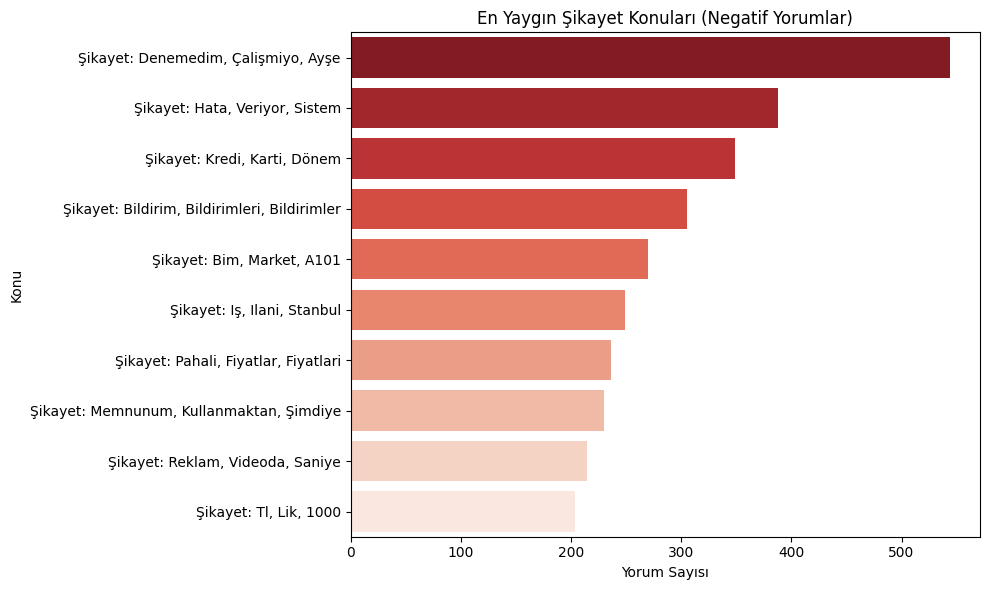

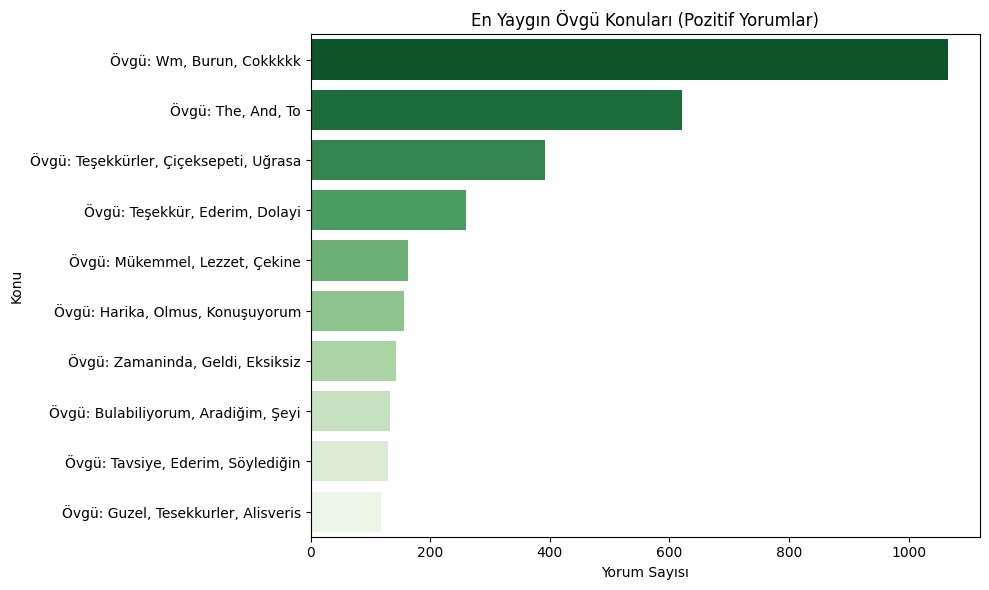

In [5]:
if bertopic_success:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Grafik 1 - Topic Büyüklükleri (Olumsuz)
    neg_counts = negative_df[negative_df['topic'] != -1]['topic'].map(neg_topic_names).value_counts().reset_index()
    neg_counts.columns = ['Konu', 'Yorum Sayısı']
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=neg_counts.head(10), x='Yorum Sayısı', y='Konu', palette='Reds_r')
    plt.title("En Yaygın Şikayet Konuları (Negatif Yorumlar)")
    plt.tight_layout()
    plt.show()
    
    # Grafik 1 - Topic Büyüklükleri (Olumlu)
    pos_counts = positive_df[positive_df['topic'] != -1]['topic'].map(pos_topic_names).value_counts().reset_index()
    pos_counts.columns = ['Konu', 'Yorum Sayısı']
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=pos_counts.head(10), x='Yorum Sayısı', y='Konu', palette='Greens_r')
    plt.title("En Yaygın Övgü Konuları (Pozitif Yorumlar)")
    plt.tight_layout()
    plt.show()

In [6]:
if bertopic_success:
    print("--- Olumsuz Konular Arası İlişki Haritası ---")
    try:
        fig_n = topic_model_neg.visualize_topics()
        if not os.path.exists('visuals'): os.makedirs('visuals')
        fig_n.write_html('visuals/neg_topics_map.html')
        print('✅ Harita kaydedildi: visuals/neg_topics_map.html')
        fig_n.show(renderer='notebook_connected')
    except Exception as e:
        print("Görselleştirme için yeterli topic bulunamadı.")
        
    print("\n--- Olumlu Konular Arası İlişki Haritası ---")
    try:
        fig_p = topic_model_pos.visualize_topics()
        if not os.path.exists('visuals'): os.makedirs('visuals')
        fig_p.write_html('visuals/pos_topics_map.html')
        print('✅ Harita kaydedildi: visuals/pos_topics_map.html')
        fig_p.show(renderer='notebook_connected')
    except Exception as e:
        print("Görselleştirme için yeterli topic bulunamadı.")

--- Olumsuz Konular Arası İlişki Haritası ---
Görselleştirme için yeterli topic bulunamadı.

--- Olumlu Konular Arası İlişki Haritası ---
Görselleştirme için yeterli topic bulunamadı.


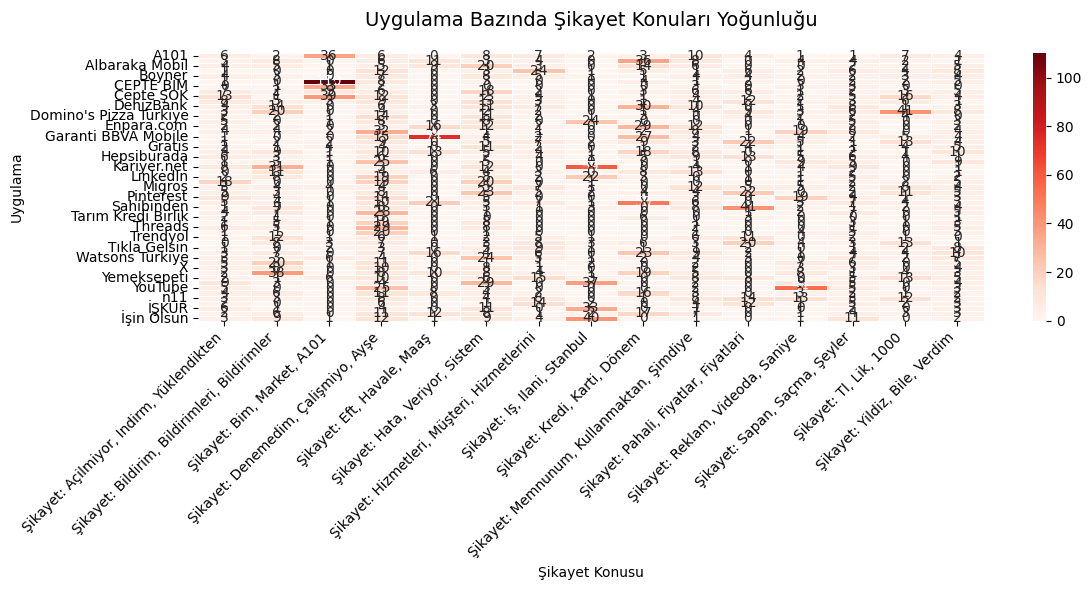

✅ Heatmap kaydedildi: visuals/topic_heatmap.png


In [7]:
if bertopic_success:
    if not os.path.exists('visuals'):
        os.makedirs('visuals')
        
    negative_df['Konu Adı'] = negative_df['topic'].map(neg_topic_names)
    # -1 (Gürültü) sınıfını dışla
    heatmap_data = negative_df[negative_df['topic'] != -1]
    
    # Sadece en çok geçen ilk 15 konuyu alalım ki grafik düzgün gözüksün
    top_15_topics = heatmap_data['Konu Adı'].value_counts().head(15).index
    heatmap_data_top = heatmap_data[heatmap_data['Konu Adı'].isin(top_15_topics)]
    
    pivot_df = pd.crosstab(heatmap_data_top['uygulama'], heatmap_data_top['Konu Adı'])
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_df, annot=True, fmt='d', cmap='Reds', linewidths=.5)
    plt.title('Uygulama Bazında Şikayet Konuları Yoğunluğu', pad=20, fontsize=14)
    plt.xlabel('Şikayet Konusu')
    plt.ylabel('Uygulama')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('visuals/topic_heatmap.png', bbox_inches='tight')
    plt.show()
    print("\u2705 Heatmap kaydedildi: visuals/topic_heatmap.png")

## Bölüm 4 — LDA Fallback
BERTopic'in (donanımsal yetersizlik veya kütüphane çakışması nedeniyle) hata vermesi durumunda, Scikit-learn/Gensim tabanlı geleneksel LDA algoritması devreye girerek Konu Modelleme işlemini tamamlar.

In [8]:
if not bertopic_success:
    print("BERTopic çalıştırılamadı, alternatif olarak Gensim LDA algoritması ile devam ediliyor...")
    from gensim import corpora, models
    import pyLDAvis
    import pyLDAvis.gensim_models
    import warnings
    warnings.filterwarnings('ignore', category=DeprecationWarning)
    
    # Metinleri parçalama (basit tokenization)
    neg_texts = [str(text).split() for text in negative_df['cleaned_text']]
    
    # Sözlük ve Corpus oluşturma
    dictionary = corpora.Dictionary(neg_texts)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in neg_texts]
    
    print("LDA Modeli eğitiliyor (8 Konu)...")
    lda_model = models.LdaModel(corpus, num_topics=8, id2word=dictionary, passes=10, random_state=42)
    
    print("\n--- LDA Konuları (Şikayetler) ---")
    for idx, topic in lda_model.print_topics(-1):
        print(f"Topic: {idx} \nWords: {topic}\n")
        
    print("LDA Görselleştirmesi Yükleniyor...")
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
    pyLDAvis.save_html(vis, 'visuals/lda_konu_modelleme.html')
    print('✅ PyLDAvis görseli oluşturuldu: visuals/lda_konu_modelleme.html (Bunu tarayıcıda açabilirsiniz)')
    display(vis)
else:
    print("\u2705 BERTopic başarıyla çalıştığı için LDA (Fallback) adımı atlandı.")

✅ BERTopic başarıyla çalıştığı için LDA (Fallback) adımı atlandı.


## Bölüm 5 — Özet Bulgular
Konu analizi üzerinden elde edilen otomatik rapor ve içgörüler (Insights):

In [9]:
from IPython.display import Markdown

if bertopic_success:
    top_neg_topics = neg_counts.head(5)
    top_pos_topics = pos_counts.head(5)
    
    # Uygulama bazında en sık rastlanan (tepe) şikayet konuları
    if not pivot_df.empty:
        top_app_topics = pivot_df.idxmax(axis=1) 
    else:
        top_app_topics = pd.Series()
    
    markdown_content = "**En Önemli 5 Şikayet Konusu:**\n"
    for i, row in top_neg_topics.iterrows():
        markdown_content += f"{i+1}. **{row['Konu']}** — {row['Yorum Sayısı']} yorum\n"
        
    markdown_content += "\n**En Önemli 5 Övgü Konusu:**\n"
    for i, row in top_pos_topics.iterrows():
        markdown_content += f"{i+1}. **{row['Konu']}** — {row['Yorum Sayısı']} yorum\n"
        
    markdown_content += "\n**Uygulama Bazında Öne Çıkan Konular:**\n"
    for app, topic in top_app_topics.items():
        markdown_content += f"- **{app}**: En çok *'{topic}'* konusunda şikayet alıyor.\n"
        
    markdown_content += "\n**Genel Yorum:**\nKullanıcı memnuniyetsizliğinin temel kaynakları yukarıda tespit edilen ilk 3 şikayet konusu etrafında toplanmaktadır. İlgili uygulamalarda operasyonel yükü azaltmak için spesifik olarak bu başlıkların çözülmesine öncelik verilmelidir. Güçlü yönler incelendiğinde ise övgü konuları, sadık kullanıcı tabanının neye değer verdiğini çok net ortaya koymaktadır. Bu özelliklerin rekabet avantajı olarak korunması gerekmektedir."
    
    display(Markdown(markdown_content))
else:
    display(Markdown("**Bilgi:** BERTopic çalışmadığı için özet bulgular otomatik oluşturulamadı. Lütfen yukarıdaki LDA grafiğini inceleyerek konuları analiz ediniz."))

**En Önemli 5 Şikayet Konusu:**
1. **Şikayet: Denemedim, Çalişmiyo, Ayşe** — 544 yorum
2. **Şikayet: Hata, Veriyor, Sistem** — 388 yorum
3. **Şikayet: Kredi, Karti, Dönem** — 349 yorum
4. **Şikayet: Bildirim, Bildirimleri, Bildirimler** — 305 yorum
5. **Şikayet: Bim, Market, A101** — 270 yorum

**En Önemli 5 Övgü Konusu:**
1. **Övgü: Wm, Burun, Cokkkkk** — 1066 yorum
2. **Övgü: The, And, To** — 621 yorum
3. **Övgü: Teşekkürler, Çiçeksepeti, Uğrasa** — 392 yorum
4. **Övgü: Teşekkür, Ederim, Dolayi** — 260 yorum
5. **Övgü: Mükemmel, Lezzet, Çekine** — 163 yorum

**Uygulama Bazında Öne Çıkan Konular:**
- **A101**: En çok *'Şikayet: Bim, Market, A101'* konusunda şikayet alıyor.
- **Akbank**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Albaraka Mobil**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **Amazon Alışveriş**: En çok *'Şikayet: Hizmetleri, Müşteri, Hizmetlerini'* konusunda şikayet alıyor.
- **Boyner**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **BİM Online**: En çok *'Şikayet: Bim, Market, A101'* konusunda şikayet alıyor.
- **CEPTE BİM**: En çok *'Şikayet: Bim, Market, A101'* konusunda şikayet alıyor.
- **CarrefourSA**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **Cepte ŞOK**: En çok *'Şikayet: Bim, Market, A101'* konusunda şikayet alıyor.
- **DeFacto**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **DenizBank**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Dolap**: En çok *'Şikayet: Tl, Lik, 1000'* konusunda şikayet alıyor.
- **Domino's Pizza Türkiye**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Eleman.net**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.
- **Enpara.com**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Facebook**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Garanti BBVA Mobile**: En çok *'Şikayet: Eft, Havale, Maaş'* konusunda şikayet alıyor.
- **Getir**: En çok *'Şikayet: Pahali, Fiyatlar, Fiyatlari'* konusunda şikayet alıyor.
- **Gratis**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **Halkbank Mobil**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Hepsiburada**: En çok *'Şikayet: Pahali, Fiyatlar, Fiyatlari'* konusunda şikayet alıyor.
- **Instagram**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Kariyer.net**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.
- **Kuveyt Türk Mobil**: En çok *'Şikayet: Memnunum, Kullanmaktan, Şimdiye'* konusunda şikayet alıyor.
- **LinkedIn**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.
- **McDonald's**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **Migros**: En çok *'Şikayet: Memnunum, Kullanmaktan, Şimdiye'* konusunda şikayet alıyor.
- **Pazarama**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **Pinterest**: En çok *'Şikayet: Reklam, Videoda, Saniye'* konusunda şikayet alıyor.
- **QNB Finansbank**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Sahibinden**: En çok *'Şikayet: Pahali, Fiyatlar, Fiyatlari'* konusunda şikayet alıyor.
- **Snapchat**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Tarım Kredi Birlik**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Telegram**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Threads**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **TikTok**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Trendyol**: En çok *'Şikayet: Bildirim, Bildirimleri, Bildirimler'* konusunda şikayet alıyor.
- **Trendyol Go**: En çok *'Şikayet: Pahali, Fiyatlar, Fiyatlari'* konusunda şikayet alıyor.
- **Tıkla Gelsin**: En çok *'Şikayet: Hizmetleri, Müşteri, Hizmetlerini'* konusunda şikayet alıyor.
- **VakıfBank Mobil**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **Watsons Türkiye**: En çok *'Şikayet: Hata, Veriyor, Sistem'* konusunda şikayet alıyor.
- **WhatsApp Messenger**: En çok *'Şikayet: Bildirim, Bildirimleri, Bildirimler'* konusunda şikayet alıyor.
- **X**: En çok *'Şikayet: Denemedim, Çalişmiyo, Ayşe'* konusunda şikayet alıyor.
- **Yapı Kredi Mobile**: En çok *'Şikayet: Bildirim, Bildirimleri, Bildirimler'* konusunda şikayet alıyor.
- **Yemeksepeti**: En çok *'Şikayet: Hizmetleri, Müşteri, Hizmetlerini'* konusunda şikayet alıyor.
- **Yenibiriş**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.
- **YouTube**: En çok *'Şikayet: Reklam, Videoda, Saniye'* konusunda şikayet alıyor.
- **Ziraat Mobil**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **n11**: En çok *'Şikayet: Pahali, Fiyatlar, Fiyatlari'* konusunda şikayet alıyor.
- **Çiçeksepeti**: En çok *'Şikayet: Hizmetleri, Müşteri, Hizmetlerini'* konusunda şikayet alıyor.
- **İŞKUR**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.
- **İşCep**: En çok *'Şikayet: Kredi, Karti, Dönem'* konusunda şikayet alıyor.
- **İşin Olsun**: En çok *'Şikayet: Iş, Ilani, Stanbul'* konusunda şikayet alıyor.

**Genel Yorum:**
Kullanıcı memnuniyetsizliğinin temel kaynakları yukarıda tespit edilen ilk 3 şikayet konusu etrafında toplanmaktadır. İlgili uygulamalarda operasyonel yükü azaltmak için spesifik olarak bu başlıkların çözülmesine öncelik verilmelidir. Güçlü yönler incelendiğinde ise övgü konuları, sadık kullanıcı tabanının neye değer verdiğini çok net ortaya koymaktadır. Bu özelliklerin rekabet avantajı olarak korunması gerekmektedir.